# TMT channel offsets — loading error, replicate noise per timepoint, loading control

Written 2026-09-15 to check on the **full hme1_2 table** what was measured on the 8723-site clustered
table (`notebooks/03_clustering/Data_clustered/20260715_*`). Every section recomputes what it needs from
`raw:abs`, so the stored derived columns are not used.

| section | question |
|---|---|
| 1 | Is missingness plex-wise (a site is in every channel of a plex, or in none)? |
| 2 | How big is each channel's offset vs the starve channel of its own plex? Which part is random (differs between plexes) and which is systematic (the same in every plex)? |
| 3 | Does removing **only the random part** (`correct_channel_offsets(keep_systematic=True)`) lower the replicate SD — also for sites seen in 2 or 3 plexes? How much does it move their `log2:FC`? |
| 4 | After the correction, is the lower SD at 5 / 10 min specific to responsive sites, and not just "brighter signal = less noise"? |
| 5 | Timing jitter: are the steepest sites extra noisy at the early timepoints? |
| 6 | Loading control: do **non-phosphorylated** peptides in the FragPipe output show the same systematic shift? |

**📤 = please send me the printed output of that cell** (the text is enough; the figures are for you).

What the correction does and does not do: it removes the plex-to-plex scatter of each channel's offset and
keeps the average (systematic) shift, so a genuine global increase in phosphorylation survives it. Whether
that systematic shift is biology or a property of the TMT channel cannot be decided from the phospho data,
because every timepoint sat in the same channel in every plex — section 6 is the test that can.

In [1]:
import os
import re
import sys
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))
from src.column_spec import ColumnSpec
from src.transformations import correct_channel_offsets

# ---- parameters ------------------------------------------------------------------------------
DATA_PATH = "../../Experiment/hme1_2/Data/Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv"
FRAGPIPE_DIR = "../../Experiment/hme1_2/Data"   # searched recursively for psm.tsv (section 6)
CELL_LINE = "WT"
CONDITIONS = ["_EGF_", "_INS_", "_EGFnINS_"]
REFERENCE = "starve"
FFDR_RESPONSIVE = 0.05   # limma omnibus F FDR below this -> "responsive"
FFDR_QUIET = 0.5         # limma omnibus F FDR above this -> "quiet" (clearly not responding)

# Plot colours: the first four categorical slots of the reference palette, one per replicate (plex).
# Every replicate also gets its own marker, so identity never depends on colour alone.
REP_COLOURS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
REP_MARKERS = ["o", "s", "^", "D"]
INK = "#52514e"
GRID = "#d9d8d3"
BEFORE_COLOUR = "#9a9993"   # recessive grey: values as stored
AFTER_COLOUR = "#2a78d6"    # corrected

# No .fillna: missing intensities must stay NaN, and this table carries limma statistics.
df = pd.read_csv(DATA_PATH, sep="\t", low_memory=False)
print(df.shape)

(50002, 484)


In [2]:
def tp_key(tp: str,) -> tuple:
    """
    Sort key for timepoint labels: full, starve, then numeric minutes.

    Args:
        tp: timepoint label, e.g. 'full', 'starve', '15'.

    Returns:
        Tuple usable as a sort key.
    """
    named = {"full": -2, "starve": -1}
    return (named[tp], 0.0) if tp in named else (0, float(tp))


def raw_layout(df: pd.DataFrame,
               condition: str,
               cell_line: str = CELL_LINE,
               data_type: str = "raw:abs",) -> dict:
    """
    Map (timepoint, replicate) to the raw replicate column of one condition.

    Args:
        df: table with {cell}_{data_type}_{treatment}_{timepoint}_{replicate} columns.
        condition: condition token with underscores, e.g. '_EGF_'.
        cell_line: cell line prefix.
        data_type: raw data type of the replicate columns.

    Returns:
        dict {(timepoint, replicate): column name}.
    """
    cols = ColumnSpec.select(df,
                             cell_lines=[cell_line],
                             data_type=data_type,
                             conditions=[condition],)
    return {(c.split("_")[-2], c.split("_")[-1]): c
            for c in cols if re.fullmatch(r"r\d+", c.split("_")[-1])}


def log2_of(df: pd.DataFrame,
            columns: list,) -> pd.DataFrame:
    """
    log2 of raw intensity columns, zeros treated as missing.

    Args:
        df: table holding the columns.
        columns: raw (linear) intensity columns.

    Returns:
        DataFrame of log2 values, NaN where the intensity is 0 or missing.
    """
    values = df[columns].astype(float)
    return np.log2(values.where(values > 0))


def timepoint_block(df: pd.DataFrame,
                    layout: dict,
                    timepoint: str,
                    reps: list,) -> pd.DataFrame:
    """
    Sites x replicates matrix of log2 intensities at one timepoint.

    Args:
        df: table with the raw replicate columns.
        layout: output of raw_layout for one condition.
        timepoint: timepoint label.
        reps: replicate labels, e.g. ['r1', 'r2', 'r3', 'r4'].

    Returns:
        DataFrame with one column per replicate.
    """
    return log2_of(df,
                   [layout[(timepoint, r)] for r in reps],)


def median_sd_by_timepoint(df: pd.DataFrame,
                           layout: dict,
                           timepoints: list,
                           reps: list,
                           mask: np.ndarray,) -> pd.Series:
    """
    Median, over the selected sites, of the across-replicate SD at each timepoint.

    Args:
        df: table with the raw replicate columns.
        layout: output of raw_layout for one condition.
        timepoints: timepoint labels to report.
        reps: replicate labels.
        mask: boolean array selecting the sites.

    Returns:
        Series indexed by timepoint (log2 units).
    """
    return pd.Series({tp: timepoint_block(df, layout, tp, reps)[mask].std(axis=1, ddof=1).median()
                      for tp in timepoints})


def mean_fc(df: pd.DataFrame,
            layout: dict,
            timepoint: str,
            reps: list,
            mask: np.ndarray,) -> pd.Series:
    """
    log2 fold change vs the reference, as the pipeline computes it: mean(t) - mean(reference)
    over the replicates in which the site was observed.

    Args:
        df: table with the raw replicate columns.
        layout: output of raw_layout for one condition.
        timepoint: timepoint label.
        reps: replicate labels.
        mask: boolean array selecting the sites.

    Returns:
        Series of log2 fold changes for the selected sites.
    """
    return (timepoint_block(df, layout, timepoint, reps)[mask].mean(axis=1)
            - timepoint_block(df, layout, REFERENCE, reps)[mask].mean(axis=1))


def site_groups(df: pd.DataFrame,
                condition: str,
                n_plex: pd.Series,) -> dict:
    """
    Site groups used in sections 3 and 4: by number of plexes detected, and by limma response.

    Args:
        df: table carrying the limma omnibus columns (if present).
        condition: condition token with underscores.
        n_plex: number of plexes each site was detected in.

    Returns:
        dict {group name: boolean array}. The responsive / quiet split is skipped with a warning
        when the omnibus FFDR column is absent. Sites limma did not test (NaN) are in neither.
    """
    groups = {f"detected in {k} plexes": (n_plex == k).to_numpy()
              for k in sorted(n_plex.unique()) if k >= 2}
    ffdr_col = f"{CELL_LINE}_log2:FFDR_{condition.strip('_')}_omnibus"
    if ffdr_col in df.columns:
        groups[f"responsive (FFDR < {FFDR_RESPONSIVE})"] = (df[ffdr_col] < FFDR_RESPONSIVE).to_numpy()
        groups[f"quiet (FFDR > {FFDR_QUIET})"] = (df[ffdr_col] > FFDR_QUIET).to_numpy()
    else:
        warnings.warn(f"{ffdr_col} not found — responsive / quiet split skipped.")
    return groups


def clean_axes(ax: plt.Axes,) -> None:
    """
    Recessive axes: no top/right spines, light horizontal grid behind the data.

    Args:
        ax: matplotlib axes.

    Returns:
        None
    """
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK, labelsize=9)
    ax.grid(axis="y", color=GRID, lw=0.6)
    ax.set_axisbelow(True)

## 1. Is missingness plex-wise? 📤

The correction estimates each channel's offset from within-plex differences, so it relies on a site
being either present in every channel of a plex or absent from all of them. 1b tells how many sites
are incomplete (seen in fewer than 4 plexes) — the ones where section 3b matters most.

In [3]:
LAYOUT = {cond: raw_layout(df, cond) for cond in CONDITIONS}
REPS = sorted({rep for cond in CONDITIONS for (_, rep) in LAYOUT[cond]})
TIMEPOINTS = sorted({tp for cond in CONDITIONS for (tp, _) in LAYOUT[cond]}, key=tp_key)
POST = [tp for tp in TIMEPOINTS if tp not in ("full", REFERENCE)]
assert len(REPS) <= len(REP_COLOURS), "more replicates than plot colours — extend REP_COLOURS"
print("replicates (plexes):", REPS)
print("timepoints:", TIMEPOINTS)

print("\n1a. Is missingness plex-wise?")
for rep in REPS:
    cols = list(dict.fromkeys(c for cond in CONDITIONS for (tp, r), c in LAYOUT[cond].items() if r == rep))
    detected = log2_of(df, cols).notna()
    partial = (detected.any(axis=1) & ~detected.all(axis=1)).mean()
    print(f"   {rep}: {len(cols)} columns, site detected in {detected.any(axis=1).mean():.1%}, "
          f"partially detected within the plex {partial:.2%}")

N_PLEX = sum(log2_of(df, [LAYOUT[CONDITIONS[0]][(REFERENCE, rep)]]).iloc[:, 0].notna().astype(int)
             for rep in REPS)
print("\n1b. Number of plexes each site was detected in (starve channel):")
print(N_PLEX.value_counts().sort_index().to_string())

print("\n1c. Are full / starve one physical channel written under every condition?")
for tp in ("full", REFERENCE):
    same = all(df[LAYOUT[cond][(tp, rep)]].equals(df[LAYOUT[CONDITIONS[0]][(tp, rep)]])
               for cond in CONDITIONS for rep in REPS if (tp, rep) in LAYOUT[cond])
    print(f"   {tp}: identical across conditions = {same}")

replicates (plexes): ['r1', 'r2', 'r3', 'r4']
timepoints: ['full', 'starve', '2', '5', '10', '15', '90']

1a. Is missingness plex-wise?
   r1: 21 columns, site detected in 53.7%, partially detected within the plex 0.01%
   r2: 21 columns, site detected in 47.8%, partially detected within the plex 0.02%
   r3: 21 columns, site detected in 68.1%, partially detected within the plex 0.01%
   r4: 21 columns, site detected in 70.8%, partially detected within the plex 0.00%

1b. Number of plexes each site was detected in (starve channel):
1    16283
2    10746
3     9505
4    13468

1c. Are full / starve one physical channel written under every condition?
   full: identical across conditions = True
   starve: identical across conditions = True


## 2. Channel offsets vs the starve channel of the same plex 📤

For every channel: the median, over the sites quantified in **every** column, of
`log2(channel) − log2(starve of the same plex)`. `systematic` is the mean over the plexes (kept by
the correction); `random_sd` is how much the plexes scatter around it (removed).

2b checks that estimating on each plex's own detected sites instead would give nearly the same offsets.

In [4]:
corrected, offsets = correct_channel_offsets(df,
                                             cell_line=CELL_LINE,
                                             conditions=CONDITIONS,
                                             reference=REFERENCE,
                                             keep_systematic=True,)
# The "stale derived columns" warning is expected: this notebook recomputes everything from raw:abs.

cond_order = [c.strip("_") for c in CONDITIONS]
table = offsets.pivot_table(index=["condition", "timepoint"], columns="replicate", values="offset")
table = table.join(offsets.groupby(["condition", "timepoint"]).agg(systematic=("systematic", "first"),
                                                                    random_sd=("random", "std")))
table = table.loc[sorted(table.index, key=lambda i: (cond_order.index(i[0]), tp_key(i[1])))]
print(f"2a. Offset vs {REFERENCE} of the same plex (log2), median over {offsets['n_sites'].iloc[0]} common sites")
print(table.round(3).to_string())

lay = LAYOUT[CONDITIONS[0]]
gaps = []
for tp in [t for t in TIMEPOINTS if t != REFERENCE]:
    for rep in REPS:
        diff = (log2_of(df, [lay[(tp, rep)]]).iloc[:, 0] - log2_of(df, [lay[(REFERENCE, rep)]]).iloc[:, 0]).dropna()
        common = offsets.loc[(offsets["column"] == lay[(tp, rep)]), "offset"].iloc[0]
        gaps.append(abs(diff.median() - common))
print(f"\n2b. {CONDITIONS[0].strip('_')}: largest |offset on the plex's own sites - offset on common sites| = {max(gaps):.3f} log2")

2a. Offset vs starve of the same plex (log2), median over 13465 common sites
                        r1     r2     r3     r4  systematic  random_sd
condition timepoint                                                   
EGF       full       0.192 -0.276 -0.211  0.089      -0.051      0.227
          2         -0.235 -0.001 -0.044  0.200      -0.020      0.179
          5          0.323  0.368  0.217  0.241       0.287      0.070
          10         0.272  0.276  0.033  0.176       0.189      0.114
          15        -0.018 -0.212 -0.026 -0.125      -0.095      0.092
          90         0.108 -0.006  0.192  0.042       0.084      0.086
INS       full       0.192 -0.276 -0.211  0.089      -0.051      0.227
          2          0.142  0.190 -0.101  0.245       0.119      0.153
          5          0.319  0.235 -0.047  0.206       0.178      0.158
          10         0.224  0.256  0.075  0.219       0.193      0.081
          15         0.077 -0.200 -0.060  0.040      -0.036      0.124


/Users/ignacionavascamacho/PycharmProjects/TMT_Data_analysis/src/transformations.py:699: UserWarning: correct_channel_offsets: 307 derived columns (e.g. 'WT_raw:mean_EGF_full') are now stale — re-run run_all_transformations on the corrected raw columns.
  warnings.warn(f"correct_channel_offsets: {len(stale)} derived columns (e.g. '{stale[0]}') are now stale — "


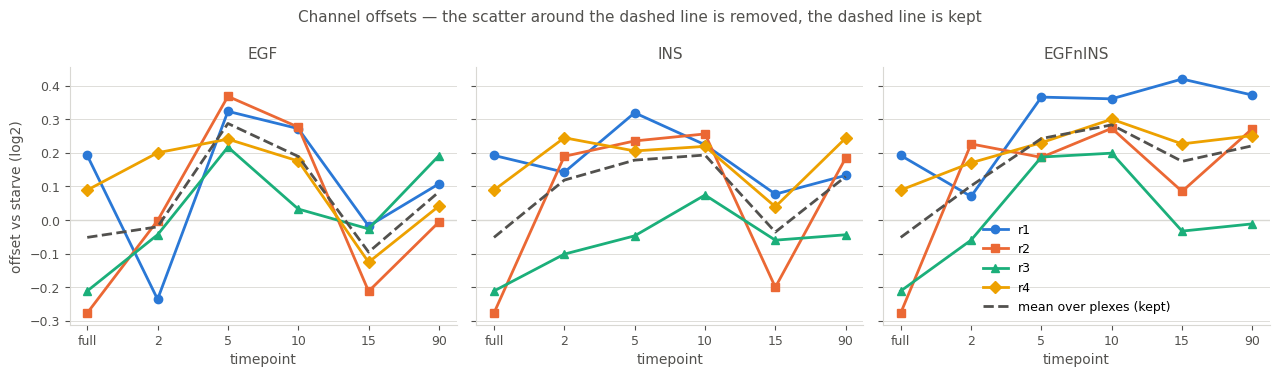

In [5]:
tps_plot = [t for t in TIMEPOINTS if t != REFERENCE]
x = np.arange(len(tps_plot))
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(4.3 * len(CONDITIONS), 3.8), sharey=True)
for ax, cond in zip(np.atleast_1d(axes), CONDITIONS):
    sub = offsets[offsets["condition"] == cond.strip("_")].set_index(["timepoint", "replicate"])
    for i, rep in enumerate(REPS):
        ax.plot(x, [sub.loc[(t, rep), "offset"] for t in tps_plot], color=REP_COLOURS[i],
                marker=REP_MARKERS[i], ms=6, lw=2, label=rep)
    ax.plot(x, [sub.loc[(t, REPS[0]), "systematic"] for t in tps_plot], color=INK, lw=2, ls="--",
            label="mean over plexes (kept)")
    ax.axhline(0, color=GRID, lw=1, zorder=0)
    ax.set_xticks(x, tps_plot)
    ax.set_title(cond.strip("_"), fontsize=11, color=INK)
    ax.set_xlabel("timepoint", color=INK)
    clean_axes(ax)
np.atleast_1d(axes)[0].set_ylabel(f"offset vs {REFERENCE} (log2)", color=INK)
np.atleast_1d(axes)[-1].legend(frameon=False, fontsize=9)
fig.suptitle("Channel offsets — the scatter around the dashed line is removed, the dashed line is kept",
             fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## 3. Replicate SD before / after removing the random part 📤

3a: median across-replicate SD per timepoint, as stored vs corrected, for sites seen in 2 / 3 / 4
plexes and for limma-responsive vs quiet sites. The starve column cannot change (it is the reference).

3b: how much the correction moves `log2:FC`. For sites seen in all 4 plexes it is exactly 0 — the
random parts sum to zero over the plexes. For sites seen in 2 or 3 plexes it is the loading bias they
inherited from *which* plexes happened to see them.

In [6]:
rows = []
for cond in CONDITIONS:
    for name, mask in site_groups(df, cond, N_PLEX).items():
        for version, data in (("as stored", df), ("corrected", corrected)):
            sd = median_sd_by_timepoint(data, LAYOUT[cond], TIMEPOINTS, REPS, mask)
            rows.append({"condition": cond.strip("_"), "group": name, "n": int(mask.sum()),
                         "version": version, **sd.round(3).to_dict()})
SD_TABLE = pd.DataFrame(rows).set_index(["condition", "group", "n", "version"])[TIMEPOINTS]
print("3a. Median across-replicate SD (log2) per timepoint")
with pd.option_context("display.width", 200):
    print(SD_TABLE.to_string())

print("\n3b. Median |change in log2:FC| caused by the correction")
for cond in CONDITIONS:
    for k in sorted(N_PLEX.unique()):
        if k < 1:
            continue
        mask = (N_PLEX == k).to_numpy()
        change = {tp: (mean_fc(corrected, LAYOUT[cond], tp, REPS, mask)
                       - mean_fc(df, LAYOUT[cond], tp, REPS, mask)).abs().median()
                  for tp in TIMEPOINTS if tp != REFERENCE}
        print(f"   {cond.strip('_'):8s} seen in {k} plexes (n={mask.sum():5d}): "
              + "  ".join(f"{tp}: {v:.3f}" for tp, v in change.items()))

3a. Median across-replicate SD (log2) per timepoint
                                                     full  starve      2      5     10     15     90
condition group                    n     version                                                    
EGF       detected in 2 plexes     10746 as stored  0.152   0.116  0.162  0.106  0.083  0.155  0.178
                                         corrected  0.118   0.116  0.117  0.112  0.101  0.119  0.123
          detected in 3 plexes     9505  as stored  0.185   0.133  0.235  0.120  0.102  0.173  0.198
                                         corrected  0.136   0.133  0.135  0.126  0.115  0.138  0.149
          detected in 4 plexes     13468 as stored  0.205   0.119  0.224  0.114  0.101  0.164  0.183
                                         corrected  0.121   0.119  0.126  0.118  0.107  0.125  0.138
          responsive (FFDR < 0.05) 20853 as stored  0.196   0.118  0.218  0.114  0.098  0.164  0.185
                                       

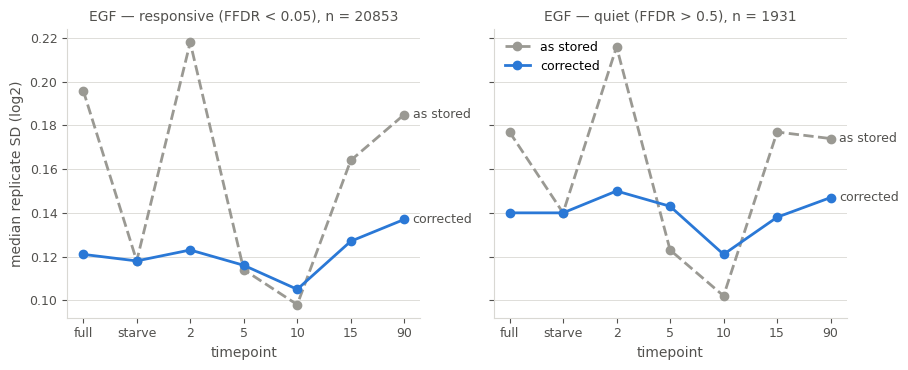

In [7]:
cond = CONDITIONS[0]
panel_groups = [g for g in site_groups(df, cond, N_PLEX) if g.startswith(("quiet", "responsive"))] \
               or [f"detected in {len(REPS)} plexes"]
fig, axes = plt.subplots(1, len(panel_groups), figsize=(4.6 * len(panel_groups), 3.8), sharey=True)
xt = np.arange(len(TIMEPOINTS))
for ax, group in zip(np.atleast_1d(axes), panel_groups):
    sub = SD_TABLE.xs((cond.strip("_"), group), level=("condition", "group"))
    n = sub.index.get_level_values("n")[0]
    for version, colour, style in (("as stored", BEFORE_COLOUR, "--"), ("corrected", AFTER_COLOUR, "-")):
        y = sub.xs(version, level="version").iloc[0].to_numpy(dtype=float)
        ax.plot(xt, y, color=colour, ls=style, lw=2, marker="o", ms=6, label=version)
        ax.annotate(version, (xt[-1], y[-1]), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9, color=INK)
    ax.set_xticks(xt, TIMEPOINTS)
    ax.set_title(f"{cond.strip('_')} — {group}, n = {n}", fontsize=10, color=INK)
    ax.set_xlabel("timepoint", color=INK)
    clean_axes(ax)
np.atleast_1d(axes)[0].set_ylabel("median replicate SD (log2)", color=INK)
np.atleast_1d(axes)[-1].legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout()
plt.show()

## 4. Is the low SD at the peak biology, or just brighter signal? 📤

In MS, brighter peptides are measured with less noise. Fit that mean–SD relation on the starve channel
(sites seen in every plex, corrected values), then compare each group's observed SD at every timepoint
with the SD expected from its intensity there. `ratio` ≈ 1 means intensity explains it; a dip at 5 / 10 min
only in responsive sites points to biology (e.g. saturation at the peak).

In [8]:
full_mask = (N_PLEX == len(REPS)).to_numpy()
ratio_rows, observed_rows = [], []
for cond in CONDITIONS:
    ref = timepoint_block(corrected, LAYOUT[cond], REFERENCE, REPS)[full_mask]
    mu0, sd0 = ref.mean(axis=1), ref.std(axis=1, ddof=1)
    ok = sd0 > 0
    slope, intercept = np.polyfit(mu0[ok], np.log(sd0[ok]), 1)
    print(f"{cond.strip('_')}: +1 log2 intensity multiplies the SD by {np.exp(slope):.2f}")
    for name, mask in site_groups(df, cond, N_PLEX).items():
        if not name.startswith(("responsive", "quiet")):
            continue
        mask = mask & full_mask
        ratio, observed = {}, {}
        for tp in TIMEPOINTS:
            block = timepoint_block(corrected, LAYOUT[cond], tp, REPS)[mask]
            sd = block.std(axis=1, ddof=1)
            expected = np.exp(intercept + slope * block.mean(axis=1))
            ratio[tp], observed[tp] = np.median(sd / expected), sd.median()
        key = {"condition": cond.strip("_"), "group": name, "n": int(mask.sum())}
        ratio_rows.append({**key, **ratio})
        observed_rows.append({**key, **observed})
idx = ["condition", "group", "n"]
print("\n4a. Observed median SD (corrected, sites seen in every plex)")
print(pd.DataFrame(observed_rows).set_index(idx)[TIMEPOINTS].round(3).to_string())
print("\n4b. Median of observed SD / SD expected from intensity")
print(pd.DataFrame(ratio_rows).set_index(idx)[TIMEPOINTS].round(2).to_string())

EGF: +1 log2 intensity multiplies the SD by 0.95
INS: +1 log2 intensity multiplies the SD by 0.95
EGFnINS: +1 log2 intensity multiplies the SD by 0.95

4a. Observed median SD (corrected, sites seen in every plex)
                                           full  starve      2      5     10     15     90
condition group                    n                                                      
EGF       responsive (FFDR < 0.05) 10780  0.118   0.116  0.122  0.114  0.105  0.124  0.136
          quiet (FFDR > 0.5)       331    0.140   0.145  0.156  0.154  0.132  0.129  0.172
INS       responsive (FFDR < 0.05) 3027   0.129   0.125  0.122  0.117  0.107  0.132  0.137
          quiet (FFDR > 0.5)       2049   0.134   0.133  0.129  0.119  0.119  0.144  0.141
EGFnINS   responsive (FFDR < 0.05) 6337   0.128   0.122  0.120  0.115  0.115  0.146  0.138
          quiet (FFDR > 0.5)       1515   0.121   0.120  0.123  0.107  0.125  0.133  0.133

4b. Median of observed SD / SD expected from intensity
   

## 5. Timing jitter 📤

If the real time between adding the stimulus and stopping the cells varies by a few seconds between
replicates, the error it causes is **rate of change × timing error** — large where a site is changing
fast, zero where it is flat. So jitter predicts that the steepest sites are *extra* noisy at that
timepoint compared with their own starve noise. The rate is taken from the neighbouring timepoints only,
so it is independent of the replicates whose SD is measured. Ratio flat across bins → no detectable jitter.

In [9]:
def minutes(tp: str,) -> float:
    """
    Timepoint label to minutes (starve = 0).

    Args:
        tp: timepoint label.

    Returns:
        Minutes after stimulation.
    """
    return 0.0 if tp == REFERENCE else float(tp)


seq = [REFERENCE] + POST
for cond in CONDITIONS:
    lay = LAYOUT[cond]
    means = {tp: timepoint_block(corrected, lay, tp, REPS)[full_mask].mean(axis=1) for tp in seq}
    sds = {tp: timepoint_block(corrected, lay, tp, REPS)[full_mask].std(axis=1, ddof=1) for tp in seq}
    print(f"\n{cond.strip('_')}: median SD(t) / SD({REFERENCE}) by rate-of-change bin (log2/min from the neighbours)")
    for j in range(1, len(seq) - 1):
        prev, tp, nxt = seq[j - 1], seq[j], seq[j + 1]
        rate = (means[nxt] - means[prev]).abs() / (minutes(nxt) - minutes(prev))
        edges = rate.quantile([0, 0.25, 0.5, 0.75, 0.9, 1.0]).to_numpy()
        edges[-1] += 1e-9
        labels = ["bottom 25%", "25-50%", "50-75%", "75-90%", "top 10%"]
        bins = pd.cut(rate, edges, labels=labels, include_lowest=True)
        ratio = (sds[tp] / sds[REFERENCE]).groupby(bins, observed=False).median()
        print(f"   {tp:>3} min (rate {prev}->{nxt}, top-10% edge {edges[4]:.2f}): "
              + "  ".join(f"{b}: {v:.2f}" for b, v in ratio.items()))


EGF: median SD(t) / SD(starve) by rate-of-change bin (log2/min from the neighbours)
     2 min (rate starve->5, top-10% edge 0.12): bottom 25%: 1.05  25-50%: 1.04  50-75%: 1.01  75-90%: 1.03  top 10%: 1.07
     5 min (rate 2->10, top-10% edge 0.07): bottom 25%: 0.98  25-50%: 0.98  50-75%: 0.96  75-90%: 1.00  top 10%: 0.85
    10 min (rate 5->15, top-10% edge 0.06): bottom 25%: 0.94  25-50%: 0.94  50-75%: 0.87  75-90%: 0.81  top 10%: 0.73
    15 min (rate 10->90, top-10% edge 0.00): bottom 25%: 0.97  25-50%: 0.98  50-75%: 1.03  75-90%: 1.16  top 10%: 1.37

INS: median SD(t) / SD(starve) by rate-of-change bin (log2/min from the neighbours)
     2 min (rate starve->5, top-10% edge 0.08): bottom 25%: 0.98  25-50%: 0.97  50-75%: 0.98  75-90%: 0.98  top 10%: 0.89
     5 min (rate 2->10, top-10% edge 0.04): bottom 25%: 0.89  25-50%: 0.89  50-75%: 0.91  75-90%: 0.90  top 10%: 0.93
    10 min (rate 5->15, top-10% edge 0.04): bottom 25%: 1.01  25-50%: 0.92  50-75%: 0.86  75-90%: 0.80  top 10%: 

## 6. Loading control: non-phosphorylated peptides

Channels are pooled **before** the phospho enrichment, so for a non-phosphorylated peptide (a
non-specific binder) the ratio between channels reflects only loading and labelling — it cannot gain
phosphorylation. Reading it side by side with the phosphopeptides of the same file:

- non-phospho ≈ phospho at 5 / 10 min → the systematic shift is technical (loading or TMT channel);
- non-phospho ≈ 0 while phospho ≈ +0.5 → the shift is specific to phosphopeptides, which supports a
  genuine global increase in phosphorylation.

### 6a. What is on disk 📤

In [10]:
psm_files = sorted(glob.glob(os.path.join(FRAGPIPE_DIR, "**", "psm.tsv"), recursive=True))
print(f"psm.tsv files under {FRAGPIPE_DIR}: {len(psm_files)}")
for p in psm_files:
    print("   ", os.path.relpath(p, FRAGPIPE_DIR))
all_tsv = sorted(glob.glob(os.path.join(FRAGPIPE_DIR, "**", "*.tsv"), recursive=True))
print(f"\nall .tsv files: {len(all_tsv)} (first 60)")
for p in all_tsv[:60]:
    print("   ", os.path.relpath(p, FRAGPIPE_DIR))
if psm_files:
    head = pd.read_csv(psm_files[0], sep="\t", nrows=5000, low_memory=False)
    print(f"\ncolumns of {os.path.relpath(psm_files[0], FRAGPIPE_DIR)}:")
    print(list(head.columns))

psm.tsv files under ../../Experiment/hme1_2/Data: 0

all .tsv files: 24 (first 60)
    All/20260427_hTERT_HEM1_2.tsv
    Processed/20260505_hTERT_HEM1_2_processes_phosphoPlus.tsv
    Processed/20260709_hTERT_HEM1_2_processed.tsv
    Processed/20260709_hTERT_HEM1_2_processed_phPlus.tsv
    Processed/20260714_hTERT_HEM1_2_processed.tsv
    Processed/20260714_hTERT_HEM1_2_processed_phPlus.tsv
    Processed/20260807_hTERT_HEM1_2_limma_pvalues.tsv
    Processed/20260807_hTERT_HEM1_2_log2_processed.tsv
    Processed/20260807_hTERT_HEM1_2_processed_phPlus.tsv
    Processed/20260817_hTERT_HEM1_2_log2_processed.tsv
    Processed/20260818_hTERT_HEM1_2_log2_processed_steps.tsv
    Processed/20260819_hTERT_HEM1_2_log2_processed_steps.tsv
    Processed/20260819_hme1_2_EGF_dataset_Martin.tsv
    Processed/2_hTERT_HME1_WT_clustering.tsv
    Processed/Full_dataset_2_hTERT_HME1.tsv
    Processed/Full_dataset_2_hTERT_HME1_diff.tsv
    Processed/Full_dataset_2_hTERT_HME1_diff_renamed.tsv
    Processed/Fu

### 6b. Non-phospho vs phospho offsets, per psm.tsv (one file = one plex) 📤

The channel columns are recognised automatically when their names contain `starve`, `full` or
`EGF_5` / `INS_2` / `EGFnINS_10`-like tokens. If the printed mapping is empty or wrong, fill
`CHANNEL_MAP` by hand, e.g. `{"sample_03": "starve", "sample_04": "EGF_2", ...}`, and re-run.

In [13]:
CHANNEL_MAP = {}                      # {"psm.tsv column": "starve" | "full" | "EGF_2" | ...}; empty = automatic
PHOSPHO_PATTERN = r"79\.96|\[80\]|\(79"
MOD_COLUMNS = ("Assigned Modifications", "Modified Peptide")


def guess_channel_map(columns: list,) -> dict:
    """
    Recognise TMT channel columns from their names.

    Args:
        columns: column names of a psm.tsv.

    Returns:
        dict {column: label}, label in 'starve', 'full' or '{treatment}_{minutes}'.
    """
    mapping = {}
    for col in columns:
        low = col.lower()
        hit = re.search(r"(EGFnINS|EGF|INS)[^A-Za-z0-9]?(\d+)(?:\s*min)?(?![0-9])", col)
        if "starve" in low:
            mapping[col] = "starve"
        elif "full" in low:
            mapping[col] = "full"
        elif hit:
            mapping[col] = f"{hit.group(1)}_{hit.group(2)}"
    return mapping


def label_key(label: str,) -> tuple:
    """
    Sort key for channel labels: full, starve, then treatment and minutes.

    Args:
        label: channel label from the channel map.

    Returns:
        Tuple usable as a sort key.
    """
    if label in ("full", "starve"):
        return ("", tp_key(label))
    treatment, tp = label.rsplit("_", 1)
    return (treatment, tp_key(tp))


def psm_channel_offsets(path: str,
                        channel_map: dict,
                        reference: str = "starve",) -> tuple:
    """
    Median log2 offset of every channel vs the reference channel, for non-phospho and phospho peptides.

    PSM intensities are summed per peptide (sequence + modifications) and only peptides quantified in
    every mapped channel are used, so both columns are computed on complete data.

    Args:
        path: psm.tsv of one plex.
        channel_map: {column: label}; must contain exactly one reference channel.
        reference: label of the reference channel.

    Returns:
        Tuple (DataFrame indexed by channel label with 'non-phospho', 'phospho' and 'difference'
        columns, dict of peptide counts per class).
    """
    psm = pd.read_csv(path, sep="\t", low_memory=False)
    cols = [c for c in channel_map if c in psm.columns]
    ref_cols = [c for c in cols if channel_map[c] == reference]
    if len(ref_cols) != 1:
        raise ValueError(f"{path}: expected one '{reference}' channel, found {ref_cols}")
    mod_cols = [c for c in MOD_COLUMNS if c in psm.columns]
    mods = psm[mod_cols].astype(str).agg(" ".join, axis=1)
    is_phospho = mods.str.contains(PHOSPHO_PATTERN, regex=True)
    key = psm["Peptide"].astype(str) + "|" + mods
    out, counts = {}, {}
    for label, mask in (("non-phospho", ~is_phospho), ("phospho", is_phospho)):
        summed = psm.loc[mask, cols].groupby(key[mask]).sum(min_count=1)
        logs = np.log2(summed.where(summed > 0))
        complete = logs.notna().all(axis=1)
        counts[label] = int(complete.sum())
        out[label] = {channel_map[c]: float(np.median(logs.loc[complete, c] - logs.loc[complete, ref_cols[0]]))
                      for c in cols if c != ref_cols[0]}
    res = pd.DataFrame(out)
    res["difference"] = res["phospho"] - res["non-phospho"]
    return res.loc[sorted(res.index, key=label_key)], counts


for path in psm_files:
    header = pd.read_csv(path, sep="\t", nrows=0).columns.tolist()
    mapping = CHANNEL_MAP or guess_channel_map(header)
    print(f"\n=== {os.path.relpath(path, FRAGPIPE_DIR)} ===")
    print("channel map:", mapping)
    if not any(v == REFERENCE for v in mapping.values()):
        print("   no reference channel recognised — fill CHANNEL_MAP by hand and re-run this cell")
        continue
    res, counts = psm_channel_offsets(path, mapping, reference=REFERENCE)
    print(f"peptides quantified in every channel: {counts}")
    print(res.round(3).to_string())

## 7. Did the bulk of sites move, or only the responders? (median vs mode) 📤

Section 6 needs FragPipe `psm.tsv` files, which are not under `Experiment/hme1_2/`. This section is the
best test the phospho table can give on its own.

For every channel, compare two summaries of the per-site difference `log2(channel) − log2(starve)`, same plex:

- the **median**, which is what section 2 used; it moves as soon as enough sites respond;
- the **mode**, the peak of the distribution. Most sites that do not respond pile up at one value, and
  the peak sits there. A loading error moves that pile, while responding sites only add a tail or a
  second bump.

How to read it:

| result | meaning |
|---|---|
| mode ≈ 0, median > 0 | the bulk did not move; the shift comes from sites that respond → no channel artefact at that timepoint, and median normalisation would subtract biology |
| mode ≈ median ≈ systematic | the whole distribution slid → either loading/labelling **or** a global increase that lifts almost every site; phospho data cannot tell these apart (needs non-phospho peptides, a proteome run, or a wet-lab total-phospho assay) |

Sanity check: the plex-to-plex scatter of the mode should reproduce the random part from section 2,
because a loading error moves the whole distribution.

In [14]:
print("7a. Non-phosphorylated peptides in this table? NumPhos counts:")
print(df["NumPhos"].value_counts(dropna=False).sort_index().to_string() if "NumPhos" in df.columns else "   no NumPhos column")

7a. Non-phosphorylated peptides in this table? NumPhos counts:
NumPhos
1    39753
2     8679
3     1570


In [15]:
from scipy.stats import gaussian_kde

MODE_GRID = np.linspace(-2.0, 2.0, 801)   # 0.005 log2 resolution


def distribution_mode(x: np.ndarray,) -> float:
    """
    Peak of a smoothed (Gaussian KDE, Scott bandwidth) distribution.

    Args:
        x: 1-D array of values, NaN-free.

    Returns:
        The grid value where the density is highest (log2 units).
    """
    return float(MODE_GRID[np.argmax(gaussian_kde(x)(MODE_GRID))])


common = np.ones(len(df), dtype=bool)
for cond in CONDITIONS:
    common &= log2_of(df, list(LAYOUT[cond].values())).notna().all(axis=1).to_numpy()
print(f"7b. median vs mode of log2(channel) - log2({REFERENCE}), same plex, {common.sum()} common sites")

rows = []
for cond in CONDITIONS:
    lay = LAYOUT[cond]
    for tp in [t for t in TIMEPOINTS if t != REFERENCE]:
        for rep in REPS:
            diff = (log2_of(df, [lay[(tp, rep)]]).iloc[:, 0] - log2_of(df, [lay[(REFERENCE, rep)]]).iloc[:, 0])[common]
            rows.append({"condition": cond.strip("_"), "timepoint": tp, "replicate": rep,
                         "median": float(np.median(diff)), "mode": distribution_mode(diff.to_numpy())})
MODES = pd.DataFrame(rows)
summary = MODES.groupby(["condition", "timepoint"]).agg(median_mean=("median", "mean"),
                                                        mode_mean=("mode", "mean"),
                                                        median_sd=("median", "std"),
                                                        mode_sd=("mode", "std"))
summary["median_minus_mode"] = summary["median_mean"] - summary["mode_mean"]
summary = summary.loc[sorted(summary.index, key=lambda i: ([c.strip("_") for c in CONDITIONS].index(i[0]), tp_key(i[1])))]
print("\nmean over plexes (systematic part) and plex-to-plex SD (random part), log2")
print(summary.round(3).to_string())
print("\nper-plex modes")
print(MODES.pivot_table(index=["condition", "timepoint"], columns="replicate", values="mode")
      .loc[summary.index].round(3).to_string())

7b. median vs mode of log2(channel) - log2(starve), same plex, 13465 common sites

mean over plexes (systematic part) and plex-to-plex SD (random part), log2
                     median_mean  mode_mean  median_sd  mode_sd  median_minus_mode
condition timepoint                                                               
EGF       full            -0.051     -0.070      0.227    0.229              0.019
          2               -0.020     -0.027      0.179    0.186              0.007
          5                0.287      0.274      0.070    0.067              0.014
          10               0.189      0.170      0.114    0.113              0.019
          15              -0.095     -0.104      0.092    0.084              0.009
          90               0.084      0.075      0.086    0.078              0.009
INS       full            -0.051     -0.070      0.227    0.229              0.019
          2                0.119      0.111      0.153    0.159              0.008
          5 

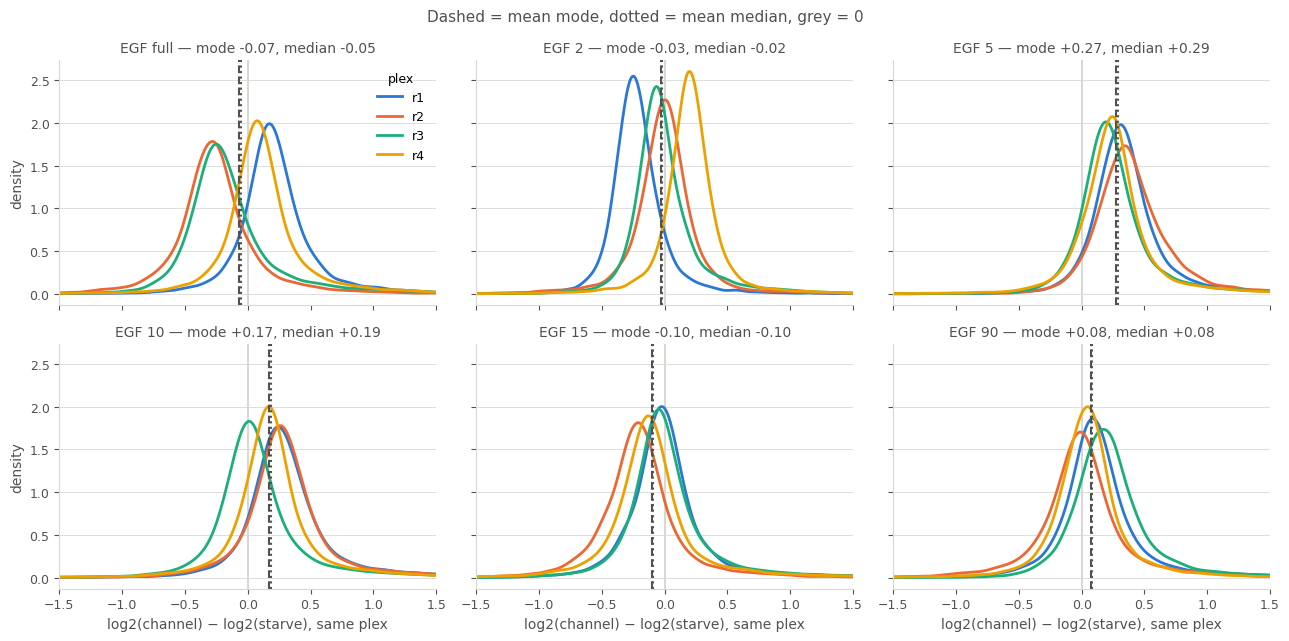

In [16]:
cond = CONDITIONS[0]
lay = LAYOUT[cond]
tps_plot = [t for t in TIMEPOINTS if t != REFERENCE]
fig, axes = plt.subplots(2, int(np.ceil(len(tps_plot) / 2)), figsize=(13, 6.5), sharex=True, sharey=True)
for ax, tp in zip(axes.ravel(), tps_plot):
    for i, rep in enumerate(REPS):
        diff = (log2_of(df, [lay[(tp, rep)]]).iloc[:, 0] - log2_of(df, [lay[(REFERENCE, rep)]]).iloc[:, 0])[common]
        ax.plot(MODE_GRID, gaussian_kde(diff.to_numpy())(MODE_GRID), color=REP_COLOURS[i], lw=2, label=rep)
    sub = summary.loc[(cond.strip("_"), tp)]
    ax.axvline(0, color=GRID, lw=1.5, zorder=0)
    ax.axvline(sub["mode_mean"], color=INK, lw=1.5, ls="--")
    ax.axvline(sub["median_mean"], color=INK, lw=1.5, ls=":")
    ax.set_title(f"{cond.strip('_')} {tp} — mode {sub['mode_mean']:+.2f}, median {sub['median_mean']:+.2f}",
                 fontsize=10, color=INK)
    ax.set_xlim(-1.5, 1.5)
    clean_axes(ax)
for ax in axes[-1]:
    ax.set_xlabel(f"log2(channel) − log2({REFERENCE}), same plex", color=INK)
for ax in axes[:, 0]:
    ax.set_ylabel("density", color=INK)
axes.ravel()[0].legend(frameon=False, fontsize=9, title="plex", title_fontsize=9)
fig.suptitle("Dashed = mean mode, dotted = mean median, grey = 0", fontsize=11, color=INK)
fig.tight_layout()
plt.show()

## What to send back

The printed output of sections 1–5, 6a (and 6b if the channel map was recognised) and 7. With it I will:
confirm the offsets and the SD pattern on the full table; decide whether the correction goes into the
preprocessing notebook ahead of `run_all_transformations` (and therefore ahead of limma); and, from 6b,
say whether the systematic shift can be claimed as a global increase in phosphorylation.